# Debug Hybrid Clustering

Simple notebook to analyze inner cluster distances.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import hdbscan
from PIL import Image
import io, base64
from IPython.display import display, HTML

sys.path.insert(0, str(Path.cwd().parent))

RESULTS_DIR = Path("../results/face_clustering_benchmark")
npy_files = sorted(RESULTS_DIR.glob("embeddings_*.npy"), reverse=True)
EMBEDDINGS_FILE = npy_files[0]
embeddings = np.load(EMBEDDINGS_FILE)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

def cosine_distance_matrix(X, Y=None):
    if Y is None: Y = X
    return np.clip(1 - X @ Y.T, 0, 2).astype(np.float64)

dist_matrix = cosine_distance_matrix(embeddings)
print(f"{len(embeddings)} faces loaded from {EMBEDDINGS_FILE.name}")

274 faces loaded from embeddings_2026-02-20_10-19-23.npy


In [ ]:
import matplotlib.pyplot as plt

def compute_all_cluster_stats(labels, k=3, n_exemplars=10):
    cluster_ids = sorted([c for c in set(labels) if c >= 0])
    rows = []
    for cid in cluster_ids:
        cluster_emb = embeddings[labels == cid]
        if len(cluster_emb) < 2:
            continue
        dists = cosine_distance_matrix(cluster_emb)
        upper_tri = dists[np.triu_indices_from(dists, k=1)]
        k_actual = min(k, len(cluster_emb) - 1)
        d3_values = np.array([np.sort(dists[i])[1:k_actual + 1][-1] for i in range(len(cluster_emb))])
        median = np.median(d3_values)
        q1, q3 = np.percentile(d3_values, [25, 75])
        iqr = q3 - q1
        
        # Exemplar statistics
        n_ex = min(n_exemplars, len(cluster_emb))
        exemplar_indices = np.argsort(d3_values)[:n_ex]
        exemplar_emb = cluster_emb[exemplar_indices]
        if len(exemplar_emb) >= 2:
            exemplar_dists = cosine_distance_matrix(exemplar_emb)
            exemplar_pw = exemplar_dists[np.triu_indices_from(exemplar_dists, k=1)]
            ex_min = exemplar_pw.min()
            ex_med = np.median(exemplar_pw)
            ex_p90 = np.percentile(exemplar_pw, 90)
            ex_max = exemplar_pw.max()
        else:
            ex_min = ex_med = ex_p90 = ex_max = 0.0
        
        rows.append({
            'cluster': cid,
            'n': len(cluster_emb),
            'n_ex': n_ex,
            'd3_min': d3_values.min(),
            'd3_p10': np.percentile(d3_values, 10),
            'd3_med': median,
            'd3_p90': np.percentile(d3_values, 90),
            'd3_max': d3_values.max(),
            'pw_min': upper_tri.min(),
            'pw_p10': np.percentile(upper_tri, 10),
            'pw_med': np.median(upper_tri),
            'pw_p90': np.percentile(upper_tri, 90),
            'pw_max': upper_tri.max(),
            'ex_min': ex_min,
            'ex_med': ex_med,
            'ex_p90': ex_p90,
            'ex_max': ex_max,
            't_med_iqr': median + 1.5 * iqr,
            't_d3_p90': np.percentile(d3_values, 90),
            't_ex_p90': ex_p90,
        })
    return pd.DataFrame(rows)

def get_face_image(face_idx):
    crops_dir = RESULTS_DIR / "face_crops"
    for pattern in [f"face_{face_idx:04d}_aligned.jpg", f"face_{face_idx:04d}.jpg"]:
        if (crops_dir / pattern).exists():
            return Image.open(crops_dir / pattern)
    return None

def show_faces(face_indices, size=60):
    html = '<div style="display:flex;flex-wrap:wrap;gap:2px;">'
    for idx in face_indices[:20]:
        img = get_face_image(idx)
        if img:
            img = img.resize((size, size))
            buffer = io.BytesIO()
            img.save(buffer, format='JPEG')
            b64 = base64.b64encode(buffer.getvalue()).decode()
            html += f'<img src="data:image/jpeg;base64,{b64}" title="#{idx}" style="border-radius:3px;">'
    html += '</div>'
    display(HTML(html))

def visualize_umap(labels, title="UMAP"):
    try:
        import umap
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
        coords = reducer.fit_transform(embeddings)
        fig, ax = plt.subplots(figsize=(12, 10))
        colors = plt.cm.tab20(np.linspace(0, 1, 20))
        for i, label in enumerate(sorted(set(labels))):
            mask = labels == label
            c = 'gray' if label == -1 else colors[i % len(colors)]
            ax.scatter(coords[mask, 0], coords[mask, 1], c=[c], s=30 if label >= 0 else 20, 
                      alpha=0.7 if label >= 0 else 0.5, label=f'C{label} ({mask.sum()})')
        ax.set_title(title, fontsize=14)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Install: pip install umap-learn")

def show_clusters(labels, max_clusters=10, faces_per_cluster=20):
    cluster_members = {cid: np.where(labels == cid)[0].tolist() for cid in set(labels) if cid >= 0}
    clusters_by_size = sorted(cluster_members.items(), key=lambda x: len(x[1]), reverse=True)
    print(f"Showing {min(max_clusters, len(clusters_by_size))} largest clusters")
    for cid, members in clusters_by_size[:max_clusters]:
        print(f"Cluster {cid}: {len(members)} faces")
        show_faces(members[:faces_per_cluster])

def show_cluster_pair(ca, cb, labels):
    members_a = np.where(labels == ca)[0].tolist()
    members_b = np.where(labels == cb)[0].tolist()
    cross = cosine_distance_matrix(embeddings[labels == ca], embeddings[labels == cb])
    print(f"Cluster {ca} ({len(members_a)}) vs {cb} ({len(members_b)})")
    print(f"Min: {cross.min():.3f} | Median: {np.median(cross):.3f}")
    print(f"\nCluster {ca}:")
    show_faces(members_a[:20])
    print(f"Cluster {cb}:")
    show_faces(members_b[:20])
    plt.figure(figsize=(10, 4))
    plt.hist(cross.flatten(), bins=30, alpha=0.6, edgecolor='black')
    plt.axvline(cross.min(), color='red', linestyle='-', linewidth=2, label=f'Min={cross.min():.3f}')
    plt.xlabel('Distance')
    plt.legend()
    plt.show()

def show_cluster_threshold_analysis(labels, cluster_id, k=3):
    cluster_emb = embeddings[labels == cluster_id]
    if len(cluster_emb) < 2:
        print(f"Cluster {cluster_id} has < 2 faces")
        return
    dists = cosine_distance_matrix(cluster_emb)
    upper_tri = dists[np.triu_indices_from(dists, k=1)]
    k_actual = min(k, len(cluster_emb) - 1)
    d3_values = np.array([np.sort(dists[i])[1:k_actual + 1][-1] for i in range(len(cluster_emb))])
    median = np.median(d3_values)
    q1, q3 = np.percentile(d3_values, [25, 75])
    iqr = q3 - q1
    p10, p90 = np.percentile(d3_values, [10, 90])
    
    print(f"Cluster {cluster_id} ({len(cluster_emb)} faces)")
    print(f"\nd3: min={d3_values.min():.3f}, P10={p10:.3f}, med={median:.3f}, P90={p90:.3f}, max={d3_values.max():.3f}")
    print(f"pairwise: min={upper_tri.min():.3f}, P10={np.percentile(upper_tri, 10):.3f}, med={np.median(upper_tri):.3f}, P90={np.percentile(upper_tri, 90):.3f}, max={upper_tri.max():.3f}")
    print(f"Thresholds: med+1.5×IQR={median + 1.5 * iqr:.3f}, P90={p90:.3f}\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    ax.hist(d3_values, bins=20, alpha=0.6, edgecolor='black')
    ax.axvline(median, color='blue', linestyle='--', linewidth=2, label=f"Median={median:.3f}")
    ax.axvline(median + 1.5 * iqr, color='green', linestyle='-', linewidth=2, label=f"Med+1.5×IQR={median + 1.5 * iqr:.3f}")
    ax.axvline(p90, color='red', linestyle='-', linewidth=2, label=f"P90={p90:.3f}")
    ax.set_xlabel(f'd3 (distance to {k}-th nearest)')
    ax.set_title(f'Cluster {cluster_id}: d3 Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(upper_tri, bins=30, alpha=0.6, edgecolor='black', color='orange')
    ax.axvline(np.median(upper_tri), color='blue', linestyle='--', linewidth=2, label=f"Median={np.median(upper_tri):.3f}")
    ax.axvline(np.percentile(upper_tri, 10), color='purple', linestyle=':', linewidth=2, label=f"P10={np.percentile(upper_tri, 10):.3f}")
    ax.axvline(np.percentile(upper_tri, 90), color='red', linestyle=':', linewidth=2, label=f"P90={np.percentile(upper_tri, 90):.3f}")
    ax.set_xlabel('Distance')
    ax.set_title(f'Cluster {cluster_id}: All Pairwise Distances')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Ready")

Ready


In [ ]:
# Test HDBSCAN configs with optional PCA
from sklearn.decomposition import PCA

configs = [
    {'name': 'No merge (leaf)', 'eps': 0.0, 'method': 'leaf', 'pca': None},
    {'name': 'Tight (eps=0.045)', 'eps': 0.045, 'method': 'eom', 'pca': None},
    {'name': 'Loose (eps=0.06)', 'eps': 0.06, 'method': 'eom', 'pca': None},
    {'name': 'PCA-128 + Tight', 'eps': 0.045, 'method': 'eom', 'pca': 128},
    {'name': 'PCA-256 + Tight', 'eps': 0.045, 'method': 'eom', 'pca': 256},
]

results = []
for cfg in configs:
    # Apply PCA if specified
    if cfg['pca'] is not None:
        pca = PCA(n_components=cfg['pca'])
        features_pca = pca.fit_transform(embeddings)
        features_pca = features_pca / np.linalg.norm(features_pca, axis=1, keepdims=True)
        dist_matrix_cfg = cosine_distance_matrix(features_pca)
        var_explained = pca.explained_variance_ratio_.sum()
        print(f"{cfg['name']}: PCA variance explained = {var_explained:.2%}")
    else:
        dist_matrix_cfg = dist_matrix
    
    # Run HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=2, min_samples=2, metric='precomputed',
        cluster_selection_epsilon=cfg['eps'],
        cluster_selection_method=cfg['method']
    )
    labels = clusterer.fit_predict(dist_matrix_cfg)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    results.append({'name': cfg['name'], 'labels': labels, 'n_clusters': n_clusters, 'n_noise': n_noise, 'pca': cfg['pca']})

df_configs = pd.DataFrame([{'config': r['name'], 'clusters': r['n_clusters'], 'noise': r['n_noise']} for r in results])
display(df_configs)

PCA-128 + Tight: PCA variance explained = 94.23%
PCA-256 + Tight: PCA variance explained = 99.93%


,config,clusters,noise
0,No merge (leaf),24,168
1,Tight (eps=0.045),8,23
2,Loose (eps=0.06),8,23
3,PCA-128 + Tight,22,104
4,PCA-256 + Tight,18,75


In [ ]:
# Select config and show inner distance statistics
selected_idx = 3  # 0-4 (try 3 or 4 for PCA configs)
labels = results[selected_idx]['labels']

print(f"\n{results[selected_idx]['name']}\n")
df_stats = compute_all_cluster_stats(labels, k=3)
display(df_stats.round(4))


PCA-128 + Tight



,cluster,n,n_ex,d3_min,d3_p10,d3_med,d3_p90,d3_max,pw_min,pw_p10,pw_med,pw_p90,pw_max,ex_min,ex_med,ex_p90,ex_max,t_med_iqr,t_d3_p90,t_ex_p90
0,0,3,3,0.0829,0.0846,0.0916,0.0916,0.0916,0.0553,0.0608,0.0829,0.0899,0.0916,0.0553,0.0829,0.0899,0.0916,0.0981,0.0916,0.0899
1,1,41,10,0.1047,0.1827,0.2648,0.5251,0.7199,0.0395,0.2647,0.4911,0.7447,0.9265,0.0395,0.2447,0.4688,0.5211,0.5535,0.5251,0.4688
2,2,6,6,0.4549,0.4912,0.6194,0.6774,0.6870,0.3304,0.3935,0.6001,0.7309,0.8300,0.3304,0.6001,0.7309,0.8300,0.7916,0.6774,0.7309
3,3,3,3,0.3886,0.4037,0.4640,0.4640,0.4640,0.3578,0.3640,0.3886,0.4489,0.4640,0.3578,0.3886,0.4489,0.4640,0.5205,0.4640,0.4489
4,4,7,7,0.1584,0.1761,0.1881,0.2847,0.3326,0.1211,0.1378,0.2102,0.3455,0.3509,0.1211,0.2102,0.3455,0.3509,0.2380,0.2847,0.3455
5,5,4,4,0.1760,0.1773,0.1908,0.2012,0.2012,0.1442,0.1463,0.1688,0.1908,0.2012,0.1442,0.1688,0.1908,0.2012,0.2237,0.2012,0.1908
6,6,2,2,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517,0.5517
7,7,5,5,0.3832,0.3953,0.4794,0.5027,0.5027,0.3422,0.3713,0.4430,0.5387,0.5580,0.3422,0.4430,0.5387,0.5580,0.6130,0.5027,0.5387
8,8,28,10,0.2397,0.2818,0.3794,0.5779,0.6255,0.1997,0.3604,0.5574,0.7647,0.9481,0.1997,0.3481,0.4382,0.5087,0.5760,0.5779,0.4382
9,9,2,2,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924,0.4924


Cluster 0: 3 faces



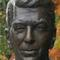
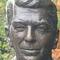
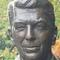

In [ ]:
# Show faces for a specific cluster
CLUSTER_ID = 0
members = np.where(labels == CLUSTER_ID)[0]
print(f"Cluster {CLUSTER_ID}: {len(members)} faces")
show_faces(members)

## UMAP-based Clustering (Exploration)

Cluster in UMAP 2D space using KMeans, then analyze with the same tools.

Computing UMAP projection...


d:\sim-bench\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering with KMeans (k=9)...


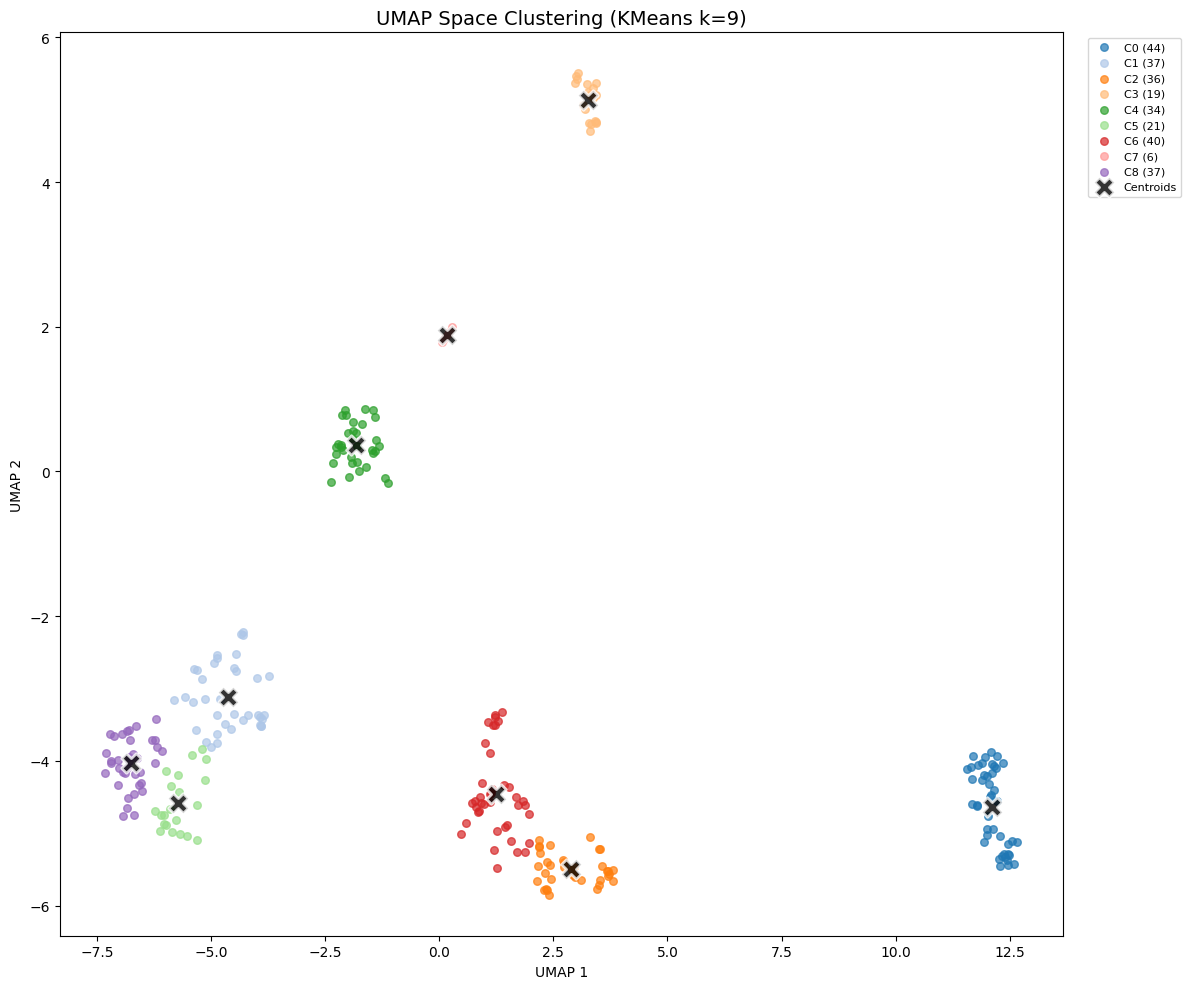


Cluster sizes: [44, 37, 36, 19, 34, 21, 40, 6, 37]
Total: 274 faces


In [ ]:
def cluster_in_umap_space(embeddings, n_clusters=10, n_neighbors=15, min_dist=0.1, random_state=42):
    """
    Cluster faces in UMAP 2D space using KMeans.
    
    Returns:
        labels: Cluster assignments
        umap_coords: 2D UMAP coordinates
        kmeans: Fitted KMeans object
    """
    try:
        import umap
        from sklearn.cluster import KMeans
        
        # Compute UMAP projection
        print(f"Computing UMAP projection...")
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=random_state)
        umap_coords = reducer.fit_transform(embeddings)
        
        # Cluster in UMAP space
        print(f"Clustering with KMeans (k={n_clusters})...")
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(umap_coords)
        
        # Visualize
        fig, ax = plt.subplots(figsize=(12, 10))
        colors = plt.cm.tab20(np.linspace(0, 1, 20))
        for i in range(n_clusters):
            mask = labels == i
            c = colors[i % len(colors)]
            ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], c=[c], s=30, 
                      alpha=0.7, label=f'C{i} ({mask.sum()})')
        
        # Plot centroids
        centroids = kmeans.cluster_centers_
        ax.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, alpha=0.8, 
                  marker='X', edgecolors='white', linewidths=2, label='Centroids')
        
        ax.set_title(f'UMAP Space Clustering (KMeans k={n_clusters})', fontsize=14)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.tight_layout()
        plt.show()
        
        cluster_sizes = [int(np.sum(labels == i)) for i in range(n_clusters)]
        print(f"\nCluster sizes: {cluster_sizes}")
        print(f"Total: {len(labels)} faces")
        
        return labels, umap_coords, kmeans
        
    except ImportError:
        print("Install: pip install umap-learn scikit-learn")
        return None, None, None

# Run UMAP-based clustering
K_CLUSTERS = 9  # Change this to try different number of clusters
umap_labels, umap_coords, kmeans_model = cluster_in_umap_space(embeddings, n_clusters=K_CLUSTERS)

In [ ]:
# Analyze UMAP clusters - Statistics table
print("Inner distance statistics for UMAP clusters:\n")
df_umap_stats = compute_all_cluster_stats(umap_labels, k=3, n_exemplars=10)
display(df_umap_stats.round(4))

Inner distance statistics for UMAP clusters:



,cluster,n,n_ex,d3_min,d3_p10,d3_med,d3_p90,d3_max,pw_min,pw_p10,pw_med,pw_p90,pw_max,ex_min,ex_med,ex_p90,ex_max,t_med_iqr,t_d3_p90,t_ex_p90
0,0,14,10,0.2008,0.2170,0.2832,0.5136,0.6448,0.1669,0.2212,0.3897,0.6840,0.8341,0.1669,0.2960,0.3907,0.4220,0.4751,0.5136,0.3907
1,1,13,10,0.4412,0.4639,0.5178,0.6583,0.8402,0.3219,0.4701,0.6339,0.8994,0.9954,0.3219,0.5664,0.7456,0.8246,0.6584,0.6583,0.7456
2,2,25,10,0.1047,0.1150,0.3016,0.7405,0.8227,0.0395,0.2153,0.5251,0.8885,0.9934,0.0395,0.2136,0.2668,0.3419,0.7367,0.7405,0.2668
3,3,19,10,0.1584,0.1795,0.2528,0.4891,0.5972,0.1211,0.2102,0.5477,0.7096,0.8052,0.1211,0.3836,0.4634,0.4966,0.6436,0.4891,0.4634
4,4,34,10,0.2397,0.2884,0.4159,0.6755,0.8805,0.1234,0.3892,0.6597,0.9358,1.0269,0.1997,0.3481,0.4382,0.5087,0.8047,0.6755,0.4382
5,5,16,10,0.2333,0.3030,0.3547,0.6975,0.8904,0.1657,0.3241,0.5251,0.9240,1.0472,0.1657,0.4402,0.5535,0.6547,0.5362,0.6975,0.5535
6,6,37,10,0.2593,0.2654,0.3656,0.5281,0.5570,0.0624,0.3534,0.5167,0.6511,0.8449,0.0624,0.3156,0.4105,0.4378,0.5911,0.5281,0.4105
7,7,17,10,0.1667,0.2102,0.3245,0.6071,0.7176,0.1525,0.2606,0.5585,0.7621,0.8737,0.1525,0.2968,0.4495,0.5378,0.7470,0.6071,0.4495
8,8,6,6,0.4549,0.4912,0.6194,0.6774,0.6870,0.3304,0.3935,0.6001,0.7309,0.8300,0.3304,0.6001,0.7309,0.8300,0.7916,0.6774,0.7309
9,9,19,10,0.1859,0.1988,0.2717,0.5676,0.7292,0.0740,0.2307,0.3741,0.7175,0.9265,0.1235,0.2549,0.3471,0.4062,0.4017,0.5676,0.3471


Showing 9 largest clusters
Cluster 0: 44 faces



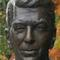
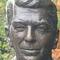
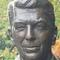
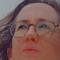
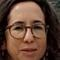
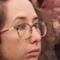
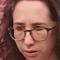
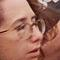
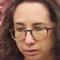
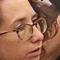
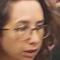
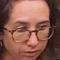
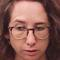
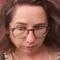
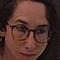
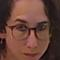
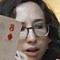
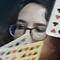
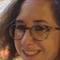
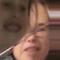

Cluster 6: 40 faces



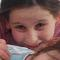
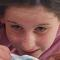
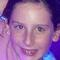
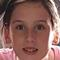
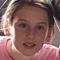
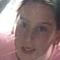
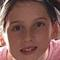
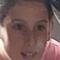
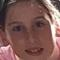
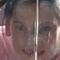
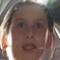
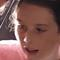
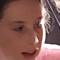
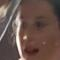
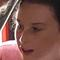
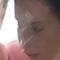
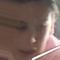
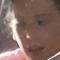
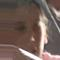
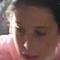

Cluster 1: 37 faces



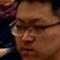
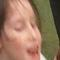
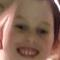
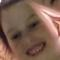
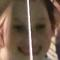
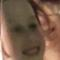
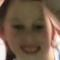
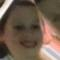
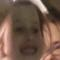
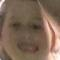
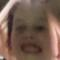
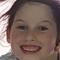
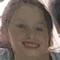
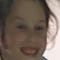
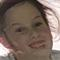
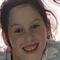
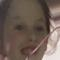
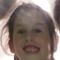
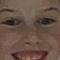
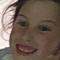

Cluster 8: 37 faces



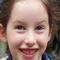
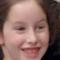
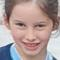
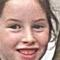
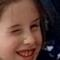
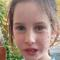
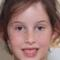
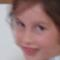
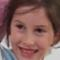
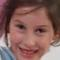
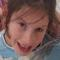
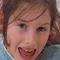
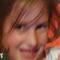
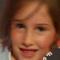
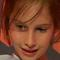
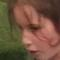
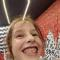
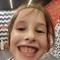
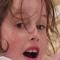
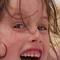

Cluster 2: 36 faces



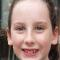
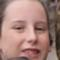
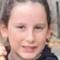
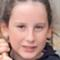
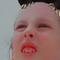
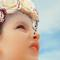
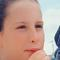
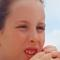
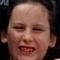
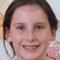
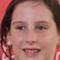
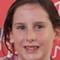
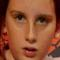
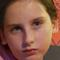
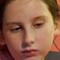
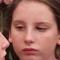
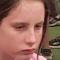
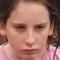
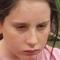
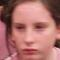

Cluster 4: 34 faces



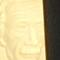
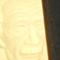
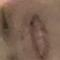
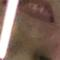
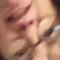
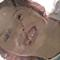
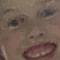
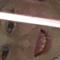
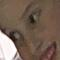
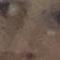
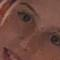
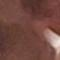
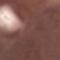
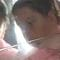
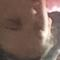
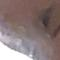
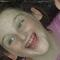
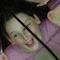
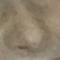
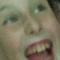

Cluster 5: 21 faces



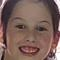
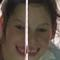
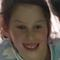
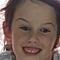
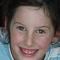
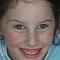
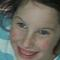
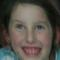
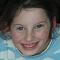
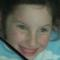
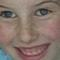
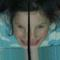
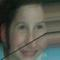
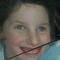
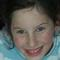
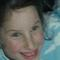
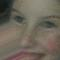
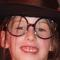
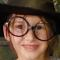
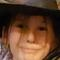

Cluster 3: 19 faces



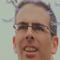
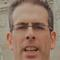
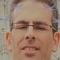
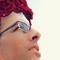
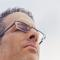
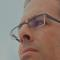
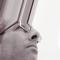
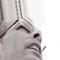
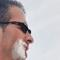
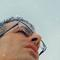
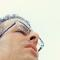
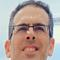
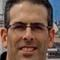
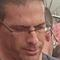
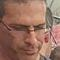
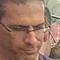
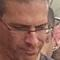
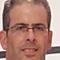
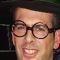

Cluster 7: 6 faces



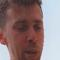
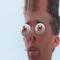
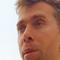
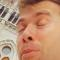
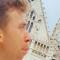
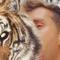

In [ ]:
# Show faces for UMAP clusters
show_clusters(umap_labels, max_clusters=10, faces_per_cluster=20)

Cluster 6 (40) vs 7 (6)
Min: 0.882 | Median: 1.021

Cluster 6:



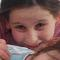
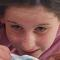
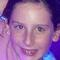
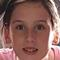
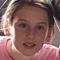
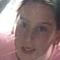
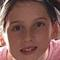
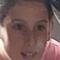
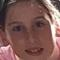
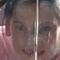
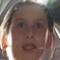
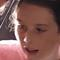
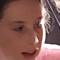
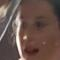
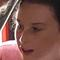
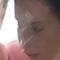
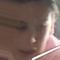
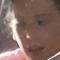
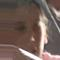
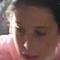

Cluster 7:



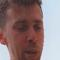
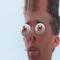
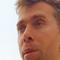
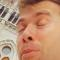
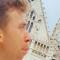
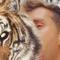

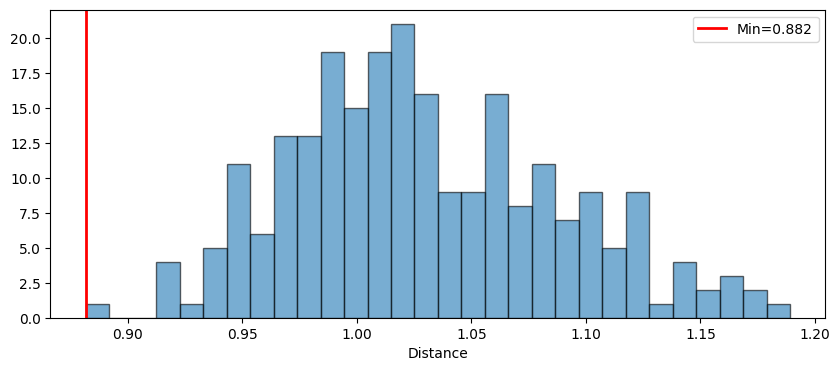

In [ ]:
# Compare two UMAP clusters
UMAP_CLUSTER_A = 6  # Change these to explore different cluster pairs
UMAP_CLUSTER_B = 7
show_cluster_pair(UMAP_CLUSTER_A, UMAP_CLUSTER_B, umap_labels)

Cluster 5 (21) vs 6 (40)
Min: 0.464 | Median: 0.732

Cluster 5:



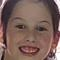
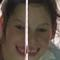
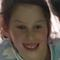
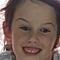
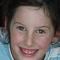
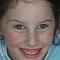
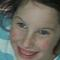
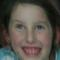
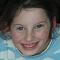
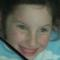
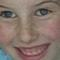
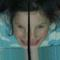
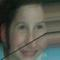
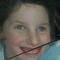
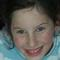
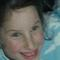
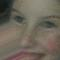
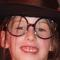
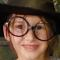
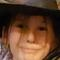

Cluster 6:



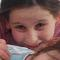
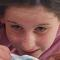
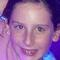
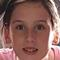
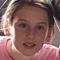
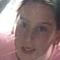
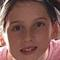
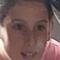
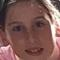
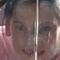
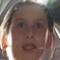
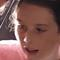
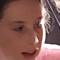
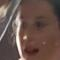
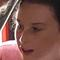
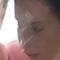
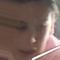
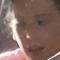
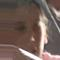
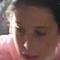

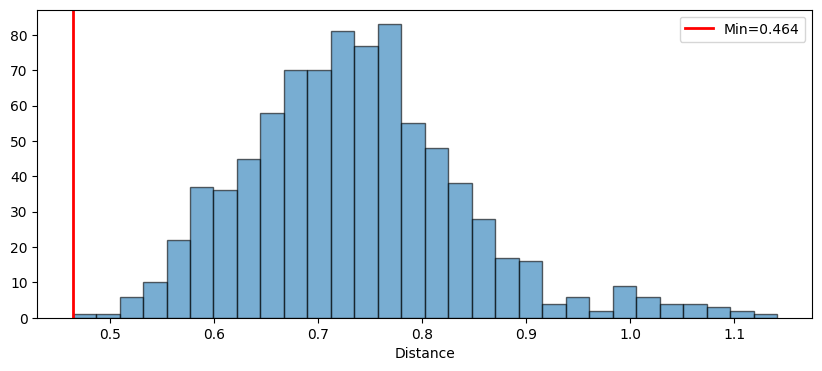

In [ ]:
# Compare two UMAP clusters
UMAP_CLUSTER_A = 5  # Change these to explore different cluster pairs
UMAP_CLUSTER_B = 6
show_cluster_pair(UMAP_CLUSTER_A, UMAP_CLUSTER_B, umap_labels)

Cluster 6 (37 faces)

d3: min=0.259, P10=0.265, med=0.366, P90=0.528, max=0.557
pairwise: min=0.062, P10=0.353, med=0.517, P90=0.651, max=0.845
Thresholds: med+1.5×IQR=0.591, P90=0.528



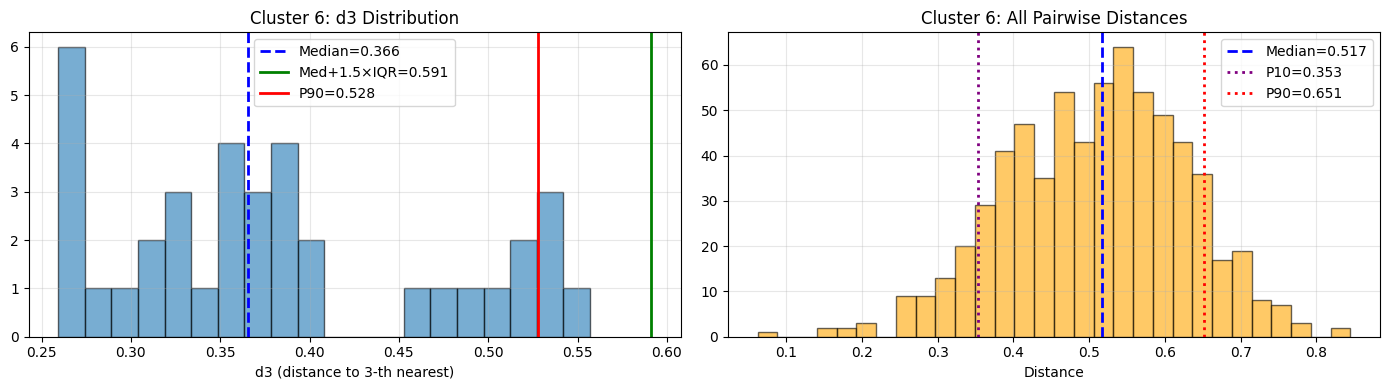

In [ ]:
# Analyze specific UMAP cluster threshold
UMAP_CLUSTER_ID = 6  # Change this to analyze different clusters
show_cluster_threshold_analysis(umap_labels, UMAP_CLUSTER_ID, k=3)

d:\sim-bench\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


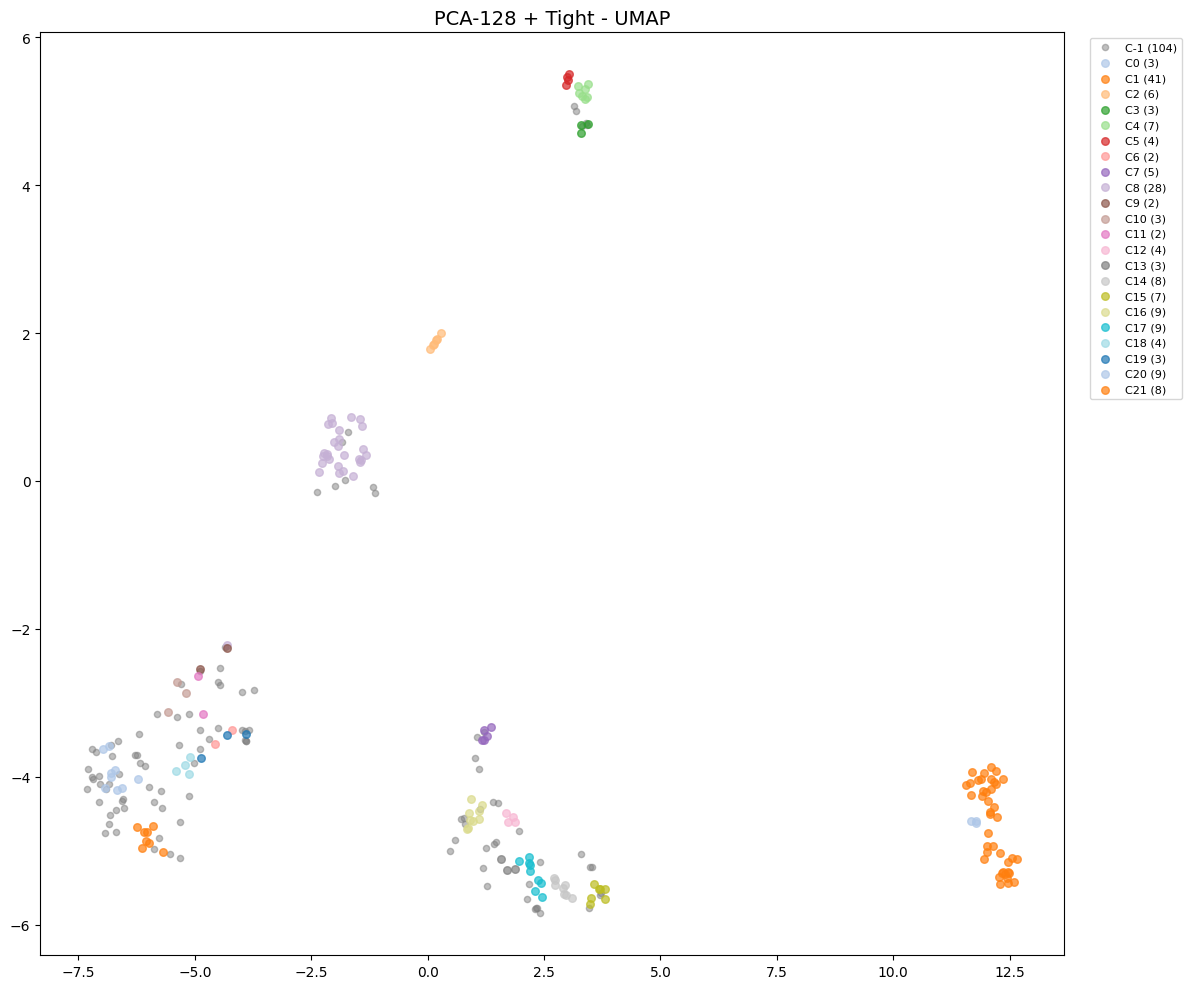

In [ ]:
# UMAP visualization
visualize_umap(labels, title=f"{results[selected_idx]['name']} - UMAP")

Showing 8 largest clusters
Cluster 1: 41 faces



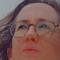
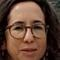
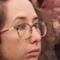
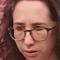
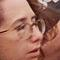
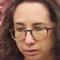
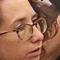
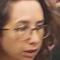
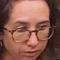
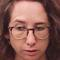
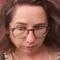
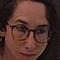
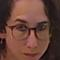
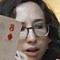
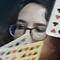
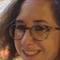
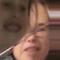
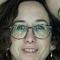
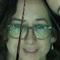
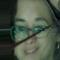

Cluster 8: 28 faces



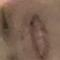
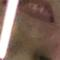
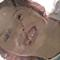
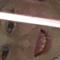
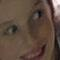
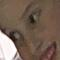
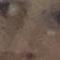
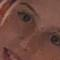
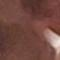
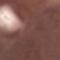
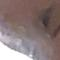
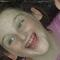
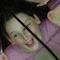
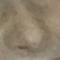
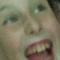
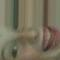
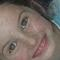
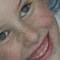
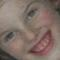
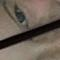

Cluster 16: 9 faces



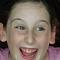
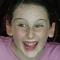
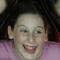
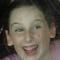
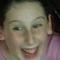
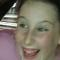
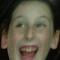
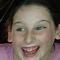
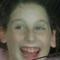

Cluster 17: 9 faces



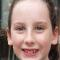
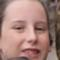
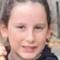
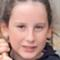
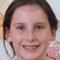
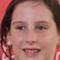
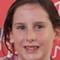
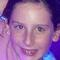
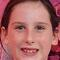

Cluster 20: 9 faces



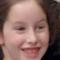
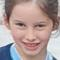
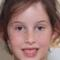
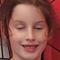
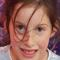
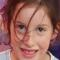
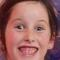
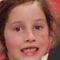
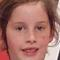

Cluster 14: 8 faces



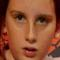
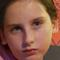
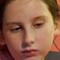
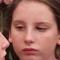
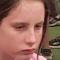
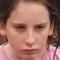
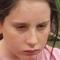
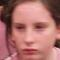

Cluster 21: 8 faces



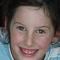
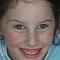
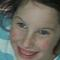
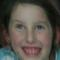
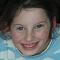
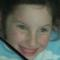
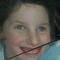
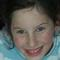

Cluster 4: 7 faces



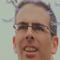
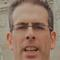
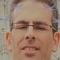
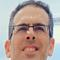
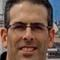
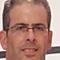
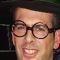

In [ ]:
# Show largest clusters with faces
show_clusters(labels, max_clusters=8, faces_per_cluster=20)

Cluster 2 (6) vs 6 (2)
Min: 0.932 | Median: 0.976

Cluster 2:



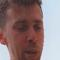
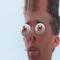
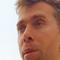
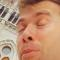
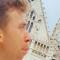
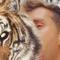

Cluster 6:



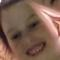
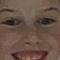

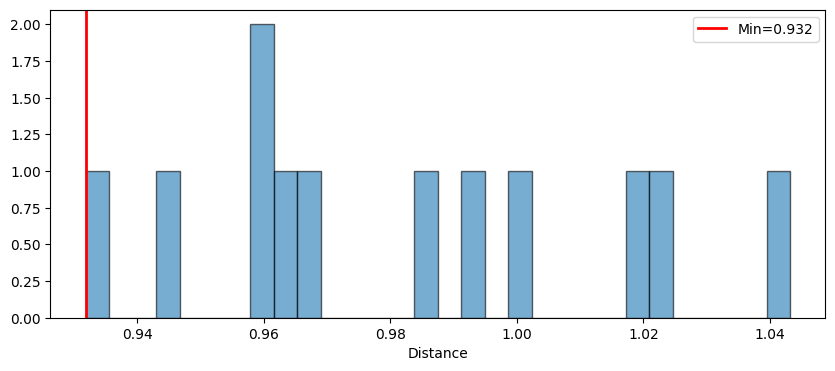

In [ ]:
# Compare two clusters
CLUSTER_A = 2
CLUSTER_B = 6
show_cluster_pair(CLUSTER_A, CLUSTER_B, labels)

Cluster 6 (2 faces, 2 exemplars)

Exemplar pairwise distances (n=1):
  Min=0.5517, Median=0.5517, P90=0.5517, Max=0.5517

All faces d3 statistics:
  Min=0.5517, Median=0.5517, P90=0.5517, Max=0.5517

Threshold comparison:
  Exemplar P90 (hybrid algorithm): 0.5517
  All-faces P90:                   0.5517
  All-faces median+1.5×IQR:                  0.5517

Exemplars (smallest d3):



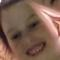
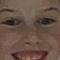

In [ ]:
# Analyze exemplar-based threshold (like hybrid algorithm)
def analyze_exemplar_threshold(labels, cluster_id, k=3, n_exemplars=10, percentile=90):
    cluster_emb = embeddings[labels == cluster_id]
    if len(cluster_emb) < 2:
        print(f"Cluster {cluster_id} has < 2 faces")
        return
    
    # Compute d3 values
    dists = cosine_distance_matrix(cluster_emb)
    k_actual = min(k, len(cluster_emb) - 1)
    d3_values = np.array([np.sort(dists[i])[1:k_actual + 1][-1] for i in range(len(cluster_emb))])
    
    # Select exemplars (smallest d3)
    n_ex = min(n_exemplars, len(cluster_emb))
    exemplar_indices = np.argsort(d3_values)[:n_ex]
    exemplar_emb = cluster_emb[exemplar_indices]
    
    # Compute exemplar pairwise distances
    exemplar_dists = cosine_distance_matrix(exemplar_emb)
    exemplar_pw = exemplar_dists[np.triu_indices_from(exemplar_dists, k=1)]
    
    # Thresholds
    t_exemplar_p90 = np.percentile(exemplar_pw, percentile)
    t_all_p90 = np.percentile(d3_values, percentile)
    t_all_med_iqr = np.median(d3_values) + 1.5 * (np.percentile(d3_values, 75) - np.percentile(d3_values, 25))
    
    print(f"Cluster {cluster_id} ({len(cluster_emb)} faces, {n_ex} exemplars)")
    print(f"\nExemplar pairwise distances (n={len(exemplar_pw)}):")
    print(f"  Min={exemplar_pw.min():.4f}, Median={np.median(exemplar_pw):.4f}, P{percentile}={t_exemplar_p90:.4f}, Max={exemplar_pw.max():.4f}")
    print(f"\nAll faces d3 statistics:")
    print(f"  Min={d3_values.min():.4f}, Median={np.median(d3_values):.4f}, P{percentile}={t_all_p90:.4f}, Max={d3_values.max():.4f}")
    print(f"\nThreshold comparison:")
    print(f"  Exemplar P{percentile} (hybrid algorithm): {t_exemplar_p90:.4f}")
    print(f"  All-faces P{percentile}:                   {t_all_p90:.4f}")
    print(f"  All-faces median+1.5×IQR:                  {t_all_med_iqr:.4f}")
    
    # Show exemplar faces
    cluster_indices = np.where(labels == cluster_id)[0]
    exemplar_global = cluster_indices[exemplar_indices]
    print(f"\nExemplars (smallest d3):")
    show_faces(exemplar_global)
    
    return {
        'exemplar_pw': exemplar_pw,
        'd3_all': d3_values,
        't_exemplar_p90': t_exemplar_p90,
        't_all_p90': t_all_p90,
        't_all_med_iqr': t_all_med_iqr
    }

# Analyze cluster 6 (the large over-merged cluster)
result = analyze_exemplar_threshold(labels, 6, k=3, n_exemplars=10, percentile=90)

Cluster 6 (2 faces)

d3: min=0.552, P10=0.552, med=0.552, P90=0.552, max=0.552
pairwise: min=0.552, P10=0.552, med=0.552, P90=0.552, max=0.552
Thresholds: med+1.5×IQR=0.552, P90=0.552



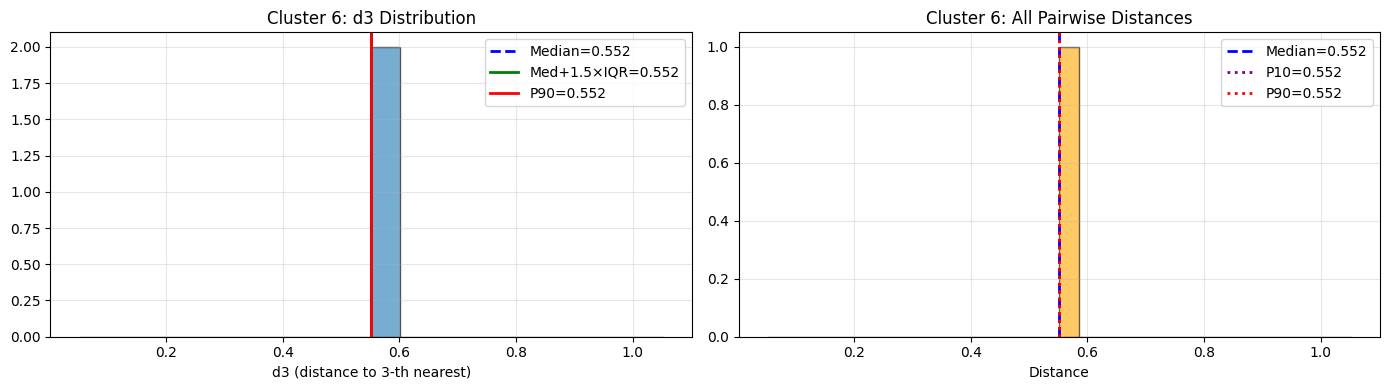

In [ ]:
# Analyze cluster threshold (distributions and statistics)
CLUSTER_ID = 6
show_cluster_threshold_analysis(labels, CLUSTER_ID, k=3)